<a href="https://colab.research.google.com/github/serahnjogu-new/Employee-churn-full-pipeline/blob/main/Employee_churn_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import pickle


Loading the Dataset

In [ ]:
df= pd.read_csv('/content/employee_churn_dataset.csv')
df.head()

,Employee ID,Age,Gender,Education Level,Marital Status,Tenure,Job Role,Department,Salary,Work Location,...,Training Hours,Promotions,Overtime Hours,Satisfaction Level,Work-Life Balance,Average Monthly Hours Worked,Absenteeism,Distance from Home,Manager Feedback Score,Churn
0,E00001,50,Male,Bachelor's,Married,5,Analyst,Marketing,93422,Remote,...,35,0,16,0.03,Poor,155,14,15,7.9,0
1,E00002,36,Male,Bachelor's,Married,4,Manager,Sales,44589,On-site,...,1,0,12,0.39,Average,162,2,8,5.2,0
2,E00003,29,Male,Bachelor's,Married,3,Sales,IT,56768,Hybrid,...,41,0,2,0.62,Poor,243,6,21,6.3,0
3,E00004,42,Male,Bachelor's,Single,12,Analyst,Sales,79009,On-site,...,33,0,8,0.73,Good,291,11,25,7.4,0
4,E00005,40,Other,Bachelor's,Married,1,Sales,HR,81982,On-site,...,30,0,13,0.52,Average,272,3,1,4.1,0


Dataset Information


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee ID                   10000 non-null  object 
 1   Age                           10000 non-null  int64  
 2   Gender                        10000 non-null  object 
 3   Education Level               10000 non-null  object 
 4   Marital Status                10000 non-null  object 
 5   Tenure                        10000 non-null  int64  
 6   Job Role                      10000 non-null  object 
 7   Department                    10000 non-null  object 
 8   Salary                        10000 non-null  int64  
 9   Work Location                 10000 non-null  object 
 10  Performance Rating            10000 non-null  int64  
 11  Projects Completed            10000 non-null  int64  
 12  Training Hours                10000 non-null  int64  
 13  Pr

In [ ]:
df.describe()

,Age,Tenure,Salary,Performance Rating,Projects Completed,Training Hours,Promotions,Overtime Hours,Satisfaction Level,Average Monthly Hours Worked,Absenteeism,Distance from Home,Manager Feedback Score,Churn
count,10000.000000,10000.000000,10000.0000,10000.0000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,40.561200,6.976800,89772.7548,3.0275,24.501200,49.715500,0.101000,24.2506,0.494940,224.53820,9.467700,24.491800,5.565430,0.202800
std,10.876483,4.296988,34469.8058,1.4120,14.444461,28.930822,0.301344,14.4787,0.287771,43.62834,5.758635,14.512491,2.595523,0.402105
min,22.000000,0.000000,30010.0000,1.0000,0.000000,0.000000,0.000000,0.0000,0.000000,150.00000,0.000000,0.000000,1.000000,0.000000
25%,31.000000,3.000000,59718.5000,2.0000,12.000000,24.750000,0.000000,12.0000,0.247500,186.00000,4.000000,12.000000,3.300000,0.000000
50%,41.000000,7.000000,89243.0000,3.0000,24.000000,49.000000,0.000000,24.0000,0.490000,225.00000,9.000000,24.000000,5.600000,0.000000
75%,50.000000,11.000000,119725.5000,4.0000,37.000000,75.000000,0.000000,37.0000,0.740000,262.25000,14.000000,37.000000,7.800000,0.000000
max,59.000000,14.000000,149993.0000,5.0000,49.000000,99.000000,1.000000,49.0000,1.000000,299.00000,19.000000,49.000000,10.000000,1.000000


Check for missing values

In [ ]:
df.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Education Level,0
Marital Status,0
Tenure,0
Job Role,0
Department,0
Salary,0
Work Location,0


In [16]:
df.shape

(10000, 22)

Exploratory Data Analysis

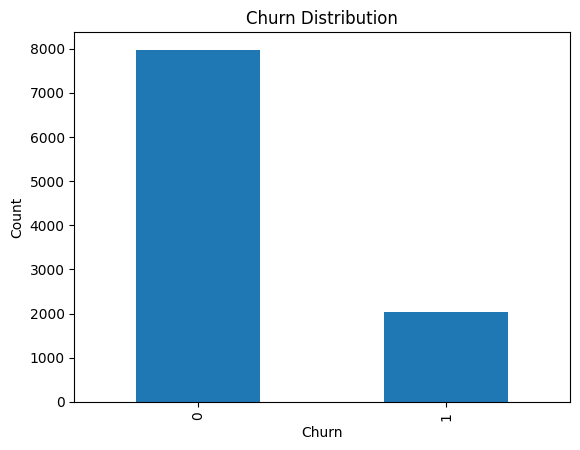

In [17]:
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

Histograms for numeric features


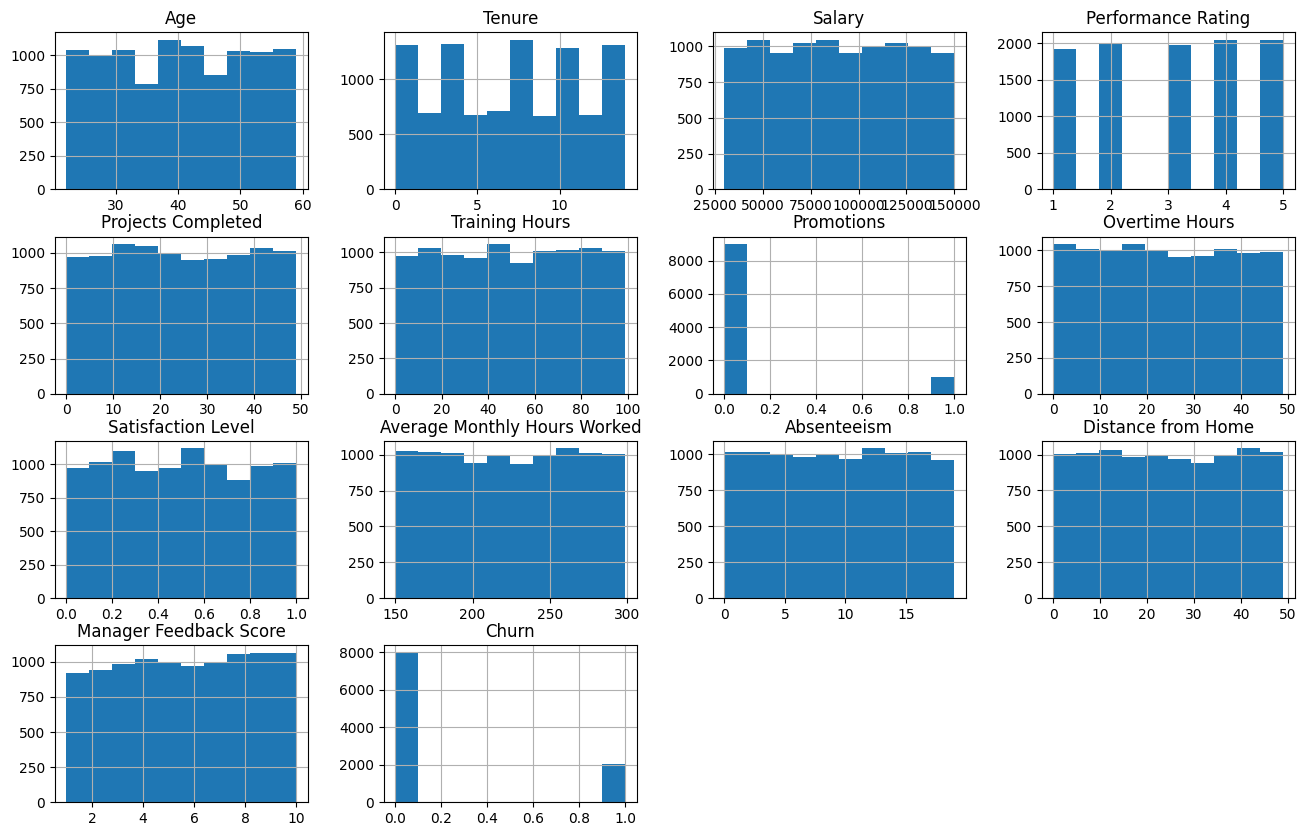

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(figsize=(16,10))
plt.show()

Churn rate by job role

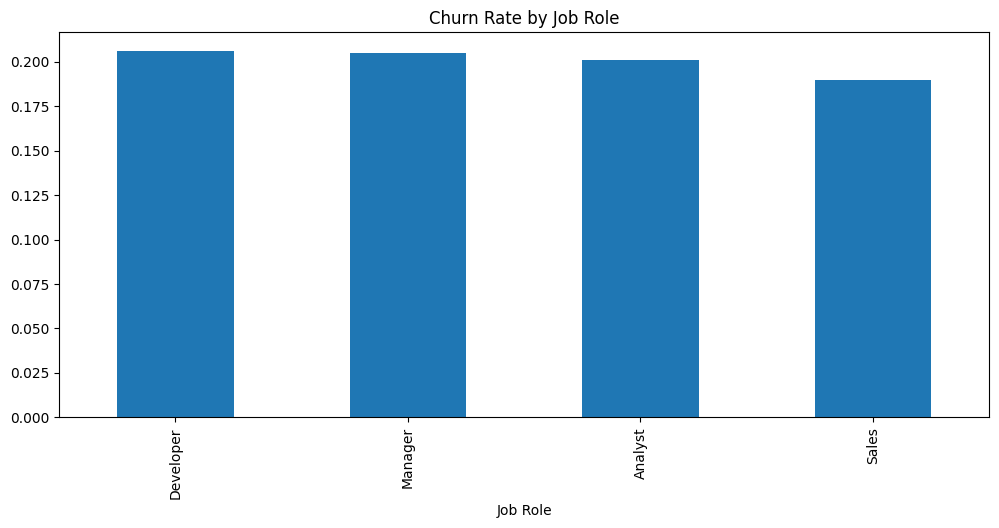

In [19]:
df.groupby('Job Role')['Churn'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title('Churn Rate by Job Role')
plt.show()

Prepare Data for ML

In [20]:
X = df.drop(['Churn','Employee ID'], errors = 'ignore')
y = df['Churn']

Train, Test and Split the data

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

Identify the numerical and categorical features and place them together


In [22]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()


Creating the Pipelines needed to train the model this  includes scaling and encoding the data


In [23]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


Training the models

In [25]:
# Logistic Regression
logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)
logreg_preds = logreg_model.predict(X_test)
logreg_probs = logreg_model.predict_proba(X_test)[:,1]

In [26]:
# Random forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=150, random_state=42))
])
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:,1]


Model Evaluation

In [27]:
# Logistic Regression Performance
print('Logistic Regression Report:')
print(classification_report(y_test, logreg_preds))
print('AUC:', roc_auc_score(y_test, logreg_probs))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1594
           1       1.00      1.00      1.00       406

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

AUC: 1.0


In [28]:
# Random forest performance
print('Random Forest Report:')
print(classification_report(y_test, rf_preds))
print('AUC:', roc_auc_score(y_test, rf_probs))


Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1594
           1       1.00      1.00      1.00       406

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

AUC: 1.0


Introducing the confusion matrix for the Random Forest


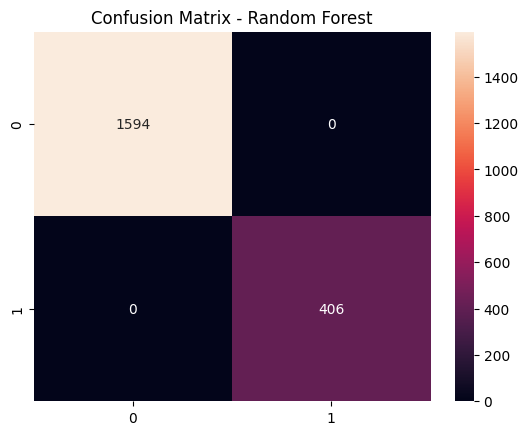

In [29]:
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Feature Importance (Random Forest)

In [31]:
# Fit preprocessor separately to extract feature names
preprocessor.fit(X_train)
num_features = numeric_features
cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

all_features = list(num_features) + list(cat_features)
importances = rf_model.named_steps['clf'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(20)


,feature,importance
13,Churn,0.781720
2,Salary,0.004948
12,Manager Feedback Score,0.004480
9,Average Monthly Hours Worked,0.004328
8,Satisfaction Level,0.004274
5,Training Hours,0.004078
7,Overtime Hours,0.004057
11,Distance from Home,0.003960
0,Age,0.003882
4,Projects Completed,0.003813


Visualizing the features


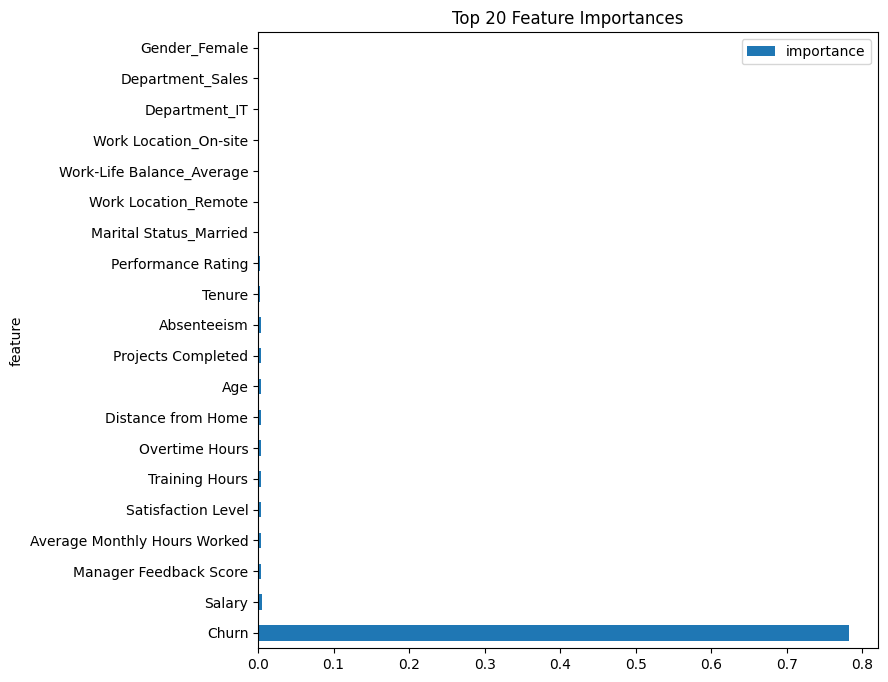

In [32]:
feat_imp.head(20).plot(kind='barh', x='feature', y='importance', figsize=(8,8))
plt.title('Top 20 Feature Importances')
plt.show()


Saving the models

In [33]:
import os
# Creates a folder
os.makedirs('/mnt/data/extracted_competition/notebook_artifacts', exist_ok=True)
# Saving the model into a file
with open('/mnt/data/extracted_competition/notebook_artifacts/logreg_model.pkl', 'wb') as f:
    pickle.dump(logreg_model, f)

with open('/mnt/data/extracted_competition/notebook_artifacts/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

'Models Saved!'

'Models Saved!'